In [1]:
import pandas as pd
import geopandas as gpd
import folium
from folium import Choropleth

In [2]:
# https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres/

valeurs_foncieres = pd.read_csv("ValeursFoncieres-2025-S1.txt", sep="|", dtype=str)
communes = gpd.read_file("cadastre-france-communes.json")
print(f"Nombre de lignes dans valeurs_foncieres : {len(valeurs_foncieres)}")
print(f"Nombre de communes : {len(communes)}")

Nombre de lignes dans valeurs_foncieres : 1387077
Nombre de communes : 34947


In [3]:
vf = valeurs_foncieres[valeurs_foncieres["Type local"].isin(["Appartement", "Maison"])]
print(f"Nombre de lignes après filtrage : {len(vf)}")

Nombre de lignes après filtrage : 404863


In [4]:
valeurs_foncieres

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,07/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,07/01/2025,Vente,...,NaN,0,1,Maison,NaN,111,5,S,NaN,133
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,07/01/2025,Vente,...,NaN,0,3,Dépendance,NaN,0,0,S,NaN,133
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,27/06/2025,Vente,...,NaN,2,2,Appartement,NaN,61,3,NaN,NaN,NaN
1387073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,27/06/2025,Vente,...,NaN,2,2,Appartement,NaN,47,2,NaN,NaN,NaN
1387074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,27/06/2025,Vente,...,NaN,2,3,Dépendance,NaN,0,0,NaN,NaN,NaN
1387075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,25/06/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
communes

,id,nom,created,updated,geometry
0,05003,AIGUILLES,2006-12-14,2017-03-17,"MULTIPOLYGON (((6.91207 44.73711, 6.91299 44.7..."
1,06011,BEAULIEU SUR MER,2005-10-05,2021-07-19,"MULTIPOLYGON (((7.3267 43.70148, 7.32691 43.70..."
2,06032,CAP-D AIL,2006-02-15,2018-06-20,"MULTIPOLYGON (((7.38991 43.71903, 7.39121 43.7..."
3,02001,ABBECOURT,2013-12-17,2018-08-06,"MULTIPOLYGON (((3.17881 49.58305, 3.1789 49.58..."
4,07004,AJOUX,2012-11-26,2023-02-14,"MULTIPOLYGON (((4.47249 44.72897, 4.4728 44.72..."
...,...,...,...,...,...
34942,71382,SAINT-AGNAN,2008-05-28,2025-07-28,"MULTIPOLYGON (((3.89278 46.48125, 3.89288 46.4..."
34943,71411,SAINT-EUGENE,2012-09-17,2025-08-08,"MULTIPOLYGON (((4.19894 46.68708, 4.19902 46.6..."
34944,71155,CRONAT,2008-05-19,2022-01-18,"MULTIPOLYGON (((3.65522 46.68767, 3.6557 46.68..."
34945,71239,ISSY-L EVEQUE,2015-05-19,2017-08-21,"MULTIPOLYGON (((3.97398 46.6477, 3.97431 46.64..."


In [6]:
# Create full commune code by combining department and commune codes
vf['full_commune_code'] = vf['Code departement'].str.zfill(2) + vf['Code commune'].str.zfill(3)

# Function to calculate average price per square meter
def calculate_avg_price_per_sqm(sales_records, property_type):
    """Calculate average price per square meter for a given property type"""
    if not sales_records:
        return None

    valid_sales = []
    for record in sales_records:
        if record.get('Type local') == property_type:
            try:
                # Get values and convert to float
                valeur = record.get('Valeur fonciere', '')
                surface = record.get('Surface reelle bati', '')

                # Handle string or numeric values
                if isinstance(valeur, str):
                    valeur = valeur.replace(',', '.').strip()
                if isinstance(surface, str):
                    surface = surface.replace(',', '.').strip()

                if valeur and surface:
                    valeur_float = float(valeur)
                    surface_float = float(surface)

                    # Only include if both values are positive
                    if valeur_float > 0 and surface_float > 0:
                        valid_sales.append(valeur_float / surface_float)
            except (ValueError, TypeError):
                continue

    return sum(valid_sales) / len(valid_sales) if valid_sales else None

# Group sales records by commune code
vf_grouped = vf.groupby("full_commune_code").apply(
    lambda x: x.to_dict('records'), include_groups=False
).reset_index(name='sales_records')

# Join with communes geodataframe
communes_with_sales = communes.merge(
    vf_grouped,
    left_on='id',
    right_on='full_commune_code',
    how='left'
)

# Convert sales_records to empty list for communes with no sales
communes_with_sales['sales_records'] = communes_with_sales['sales_records'].apply(
    lambda x: x if isinstance(x, list) else []
)

# Calculate average prices per square meter for apartments and houses
communes_with_sales['avg_price_per_sqm_apartment'] = communes_with_sales['sales_records'].apply(
    lambda x: calculate_avg_price_per_sqm(x, 'Appartement')
)
communes_with_sales['avg_price_per_sqm_house'] = communes_with_sales['sales_records'].apply(
    lambda x: calculate_avg_price_per_sqm(x, 'Maison')
)

# Add a count column for convenience
communes_with_sales['sales_count'] = communes_with_sales['sales_records'].apply(len)

print(f"Result shape: {communes_with_sales.shape}")
print(f"Communes with sales: {(communes_with_sales['sales_count'] > 0).sum()}")
print(f"Communes with apartment data: {communes_with_sales['avg_price_per_sqm_apartment'].notna().sum()}")
print(f"Communes with house data: {communes_with_sales['avg_price_per_sqm_house'].notna().sum()}")
communes_with_sales.head()


/var/folders/nz/8f1znby90q17dz1y25g4208h0000gn/T/ipykernel_71998/1922397562.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vf['full_commune_code'] = vf['Code departement'].str.zfill(2) + vf['Code commune'].str.zfill(3)


Result shape: (34947, 10)
Communes with sales: 25531
Communes with apartment data: 6860
Communes with house data: 25242


,id,nom,created,updated,geometry,full_commune_code,sales_records,avg_price_per_sqm_apartment,avg_price_per_sqm_house,sales_count
0,05003,AIGUILLES,2006-12-14,2017-03-17,"MULTIPOLYGON (((6.91207 44.73711, 6.91299 44.7...",05003,"[{'Identifiant de document': nan, 'Reference d...",1727.025131,2570.998279,7
1,06011,BEAULIEU SUR MER,2005-10-05,2021-07-19,"MULTIPOLYGON (((7.3267 43.70148, 7.32691 43.70...",06011,"[{'Identifiant de document': nan, 'Reference d...",13899.975400,26730.191534,76
2,06032,CAP-D AIL,2006-02-15,2018-06-20,"MULTIPOLYGON (((7.38991 43.71903, 7.39121 43.7...",06032,"[{'Identifiant de document': nan, 'Reference d...",8973.823640,72888.127446,43
3,02001,ABBECOURT,2013-12-17,2018-08-06,"MULTIPOLYGON (((3.17881 49.58305, 3.1789 49.58...",02001,"[{'Identifiant de document': nan, 'Reference d...",NaN,1023.924833,4
4,07004,AJOUX,2012-11-26,2023-02-14,"MULTIPOLYGON (((4.47249 44.72897, 4.4728 44.72...",07004,"[{'Identifiant de document': nan, 'Reference d...",NaN,1753.007185,4


In [7]:
communes_with_sales

,id,nom,created,updated,geometry,full_commune_code,sales_records,avg_price_per_sqm_apartment,avg_price_per_sqm_house,sales_count
0,05003,AIGUILLES,2006-12-14,2017-03-17,"MULTIPOLYGON (((6.91207 44.73711, 6.91299 44.7...",05003,"[{'Identifiant de document': nan, 'Reference d...",1727.025131,2570.998279,7
1,06011,BEAULIEU SUR MER,2005-10-05,2021-07-19,"MULTIPOLYGON (((7.3267 43.70148, 7.32691 43.70...",06011,"[{'Identifiant de document': nan, 'Reference d...",13899.975400,26730.191534,76
2,06032,CAP-D AIL,2006-02-15,2018-06-20,"MULTIPOLYGON (((7.38991 43.71903, 7.39121 43.7...",06032,"[{'Identifiant de document': nan, 'Reference d...",8973.823640,72888.127446,43
3,02001,ABBECOURT,2013-12-17,2018-08-06,"MULTIPOLYGON (((3.17881 49.58305, 3.1789 49.58...",02001,"[{'Identifiant de document': nan, 'Reference d...",NaN,1023.924833,4
4,07004,AJOUX,2012-11-26,2023-02-14,"MULTIPOLYGON (((4.47249 44.72897, 4.4728 44.72...",07004,"[{'Identifiant de document': nan, 'Reference d...",NaN,1753.007185,4
...,...,...,...,...,...,...,...,...,...,...
34942,71382,SAINT-AGNAN,2008-05-28,2025-07-28,"MULTIPOLYGON (((3.89278 46.48125, 3.89288 46.4...",71382,"[{'Identifiant de document': nan, 'Reference d...",1517.662404,1107.375520,9
34943,71411,SAINT-EUGENE,2012-09-17,2025-08-08,"MULTIPOLYGON (((4.19894 46.68708, 4.19902 46.6...",71411,"[{'Identifiant de document': nan, 'Reference d...",NaN,1952.511474,2
34944,71155,CRONAT,2008-05-19,2022-01-18,"MULTIPOLYGON (((3.65522 46.68767, 3.6557 46.68...",71155,"[{'Identifiant de document': nan, 'Reference d...",NaN,763.076199,7
34945,71239,ISSY-L EVEQUE,2015-05-19,2017-08-21,"MULTIPOLYGON (((3.97398 46.6477, 3.97431 46.64...",71239,"[{'Identifiant de document': nan, 'Reference d...",NaN,1086.525484,8


In [8]:
# Simple outlier removal with hardcoded reasonable limits
communes_cleaned = communes_with_sales.copy()

# Define reasonable price ranges (€/m²)
MIN_PRICE = 500
MAX_PRICE_APARTMENT = 15000
MAX_PRICE_HOUSE = 8000

# Remove outliers for apartments
communes_cleaned.loc[
    (communes_cleaned['avg_price_per_sqm_apartment'] < MIN_PRICE) | 
    (communes_cleaned['avg_price_per_sqm_apartment'] > MAX_PRICE_APARTMENT),
    'avg_price_per_sqm_apartment'
] = None

# Remove outliers for houses
communes_cleaned.loc[
    (communes_cleaned['avg_price_per_sqm_house'] < MIN_PRICE) | 
    (communes_cleaned['avg_price_per_sqm_house'] > MAX_PRICE_HOUSE),
    'avg_price_per_sqm_house'
] = None

print(f"Price limits applied:")
print(f"  Min price: {MIN_PRICE} €/m²")
print(f"  Max apartment price: {MAX_PRICE_APARTMENT} €/m²")
print(f"  Max house price: {MAX_PRICE_HOUSE} €/m²")
print(f"\nApartments with data (after cleaning): {communes_cleaned['avg_price_per_sqm_apartment'].notna().sum()}")
print(f"Houses with data (after cleaning): {communes_cleaned['avg_price_per_sqm_house'].notna().sum()}")

Price limits applied:
  Min price: 500 €/m²
  Max apartment price: 15000 €/m²
  Max house price: 8000 €/m²

Apartments with data (after cleaning): 6552
Houses with data (after cleaning): 24012


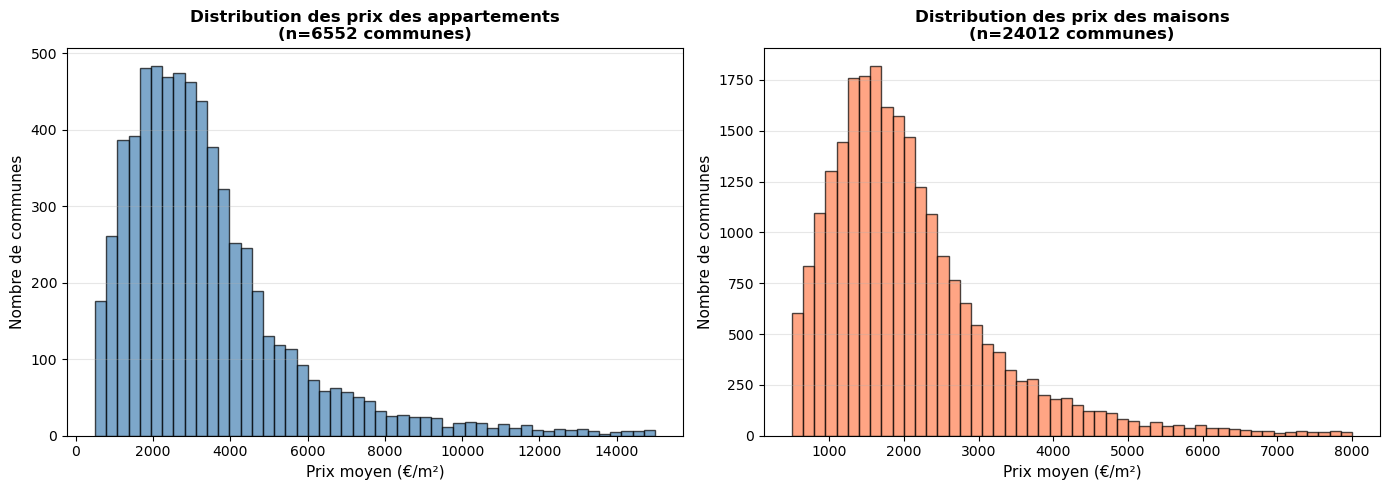


=== Statistiques des prix des appartements ===
Moyenne: 3414.98 €/m²
Médiane: 2913.19 €/m²
Min: 500.00 €/m²
Max: 14991.16 €/m²

=== Statistiques des prix des maisons ===
Moyenne: 2077.24 €/m²
Médiane: 1829.77 €/m²
Min: 500.00 €/m²
Max: 8000.00 €/m²


In [9]:
import matplotlib.pyplot as plt

# Prepare data for histogram using cleaned data
apartment_prices = communes_cleaned['avg_price_per_sqm_apartment'].dropna()
house_prices = communes_cleaned['avg_price_per_sqm_house'].dropna()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for apartments
ax1.hist(apartment_prices, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Prix moyen (€/m²)', fontsize=11)
ax1.set_ylabel('Nombre de communes', fontsize=11)
ax1.set_title(f'Distribution des prix des appartements\n(n={len(apartment_prices)} communes)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Histogram for houses
ax2.hist(house_prices, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Prix moyen (€/m²)', fontsize=11)
ax2.set_ylabel('Nombre de communes', fontsize=11)
ax2.set_title(f'Distribution des prix des maisons\n(n={len(house_prices)} communes)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Statistiques des prix des appartements ===")
print(f"Moyenne: {apartment_prices.mean():.2f} €/m²")
print(f"Médiane: {apartment_prices.median():.2f} €/m²")
print(f"Min: {apartment_prices.min():.2f} €/m²")
print(f"Max: {apartment_prices.max():.2f} €/m²")

print("\n=== Statistiques des prix des maisons ===")
print(f"Moyenne: {house_prices.mean():.2f} €/m²")
print(f"Médiane: {house_prices.median():.2f} €/m²")
print(f"Min: {house_prices.min():.2f} €/m²")
print(f"Max: {house_prices.max():.2f} €/m²")

In [10]:


# Create a function to generate the map
def create_price_map(gdf, column, title):
    """
    Create an interactive choropleth map for property prices

    Parameters:
    - gdf: GeoDataFrame with commune geometries and price data
    - column: Column name to visualize ('avg_price_per_sqm_apartment' or 'avg_price_per_sqm_house')
    - title: Title for the map
    """
    # Filter out communes without data for this property type
    gdf_filtered = gdf[gdf[column].notna()].copy()

    # Convert to WGS84 (EPSG:4326) if needed for folium
    if gdf_filtered.crs != "EPSG:4326":
        gdf_filtered = gdf_filtered.to_crs("EPSG:4326")
    
    # Keep only necessary columns and convert to JSON-serializable types
    gdf_filtered = gdf_filtered[['id', 'nom', column, 'sales_count', 'geometry']].copy()
    
    # Convert all non-geometry columns to appropriate types
    gdf_filtered['id'] = gdf_filtered['id'].astype(str)
    gdf_filtered['nom'] = gdf_filtered['nom'].astype(str)
    gdf_filtered[column] = gdf_filtered[column].astype(float)
    gdf_filtered['sales_count'] = gdf_filtered['sales_count'].astype(int)

    # Calculate map center
    center_lat = gdf_filtered.geometry.centroid.y.mean()
    center_lon = gdf_filtered.geometry.centroid.x.mean()
    print(f"Map center: lat={center_lat}, lon={center_lon}")

    # Create base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=6,
        tiles='OpenStreetMap'
    )

    # Create choropleth layer
    choropleth = Choropleth(
        geo_data=gdf_filtered,
        data=gdf_filtered,
        columns=['id', column],
        key_on='feature.properties.id',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=f'{title} (€/m²)',
        nan_fill_color='lightgray'
    ).add_to(m)

    # Add tooltips with commune info
    choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(
            fields=['nom', column, 'sales_count'],
            aliases=['Commune:', 'Prix moyen (€/m²):', 'Nombre de ventes:'],
            localize=True,
            sticky=False,
            labels=True,
            style="""
                background-color: #F0EFEF;
                border: 2px solid black;
                border-radius: 3px;
                box-shadow: 3px;
            """,
        )
    )

    return m

# Create maps for both property types using cleaned data
print("Creating map for apartments...")
map_apartments = create_price_map(
    communes_cleaned,
    'avg_price_per_sqm_apartment',
    'Prix moyen des appartements'
)

print("Creating map for houses...")
map_houses = create_price_map(
    communes_cleaned,
    'avg_price_per_sqm_house',
    'Prix moyen des maisons'
)

# Save maps to HTML files
map_apartments.save('prix_appartements.html')
map_houses.save('prix_maisons.html')

print("\nMaps created successfully!")
print("- prix_appartements.html: Interactive map of apartment prices")
print("- prix_maisons.html: Interactive map of house prices")
print("\nYou can open these HTML files in your browser to explore the data.")

Creating map for apartments...


/var/folders/nz/8f1znby90q17dz1y25g4208h0000gn/T/ipykernel_71998/3865467596.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf_filtered.geometry.centroid.y.mean()
/var/folders/nz/8f1znby90q17dz1y25g4208h0000gn/T/ipykernel_71998/3865467596.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf_filtered.geometry.centroid.x.mean()


Map center: lat=46.386702037693624, lon=3.0825142815952007
Creating map for houses...


/var/folders/nz/8f1znby90q17dz1y25g4208h0000gn/T/ipykernel_71998/3865467596.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf_filtered.geometry.centroid.y.mean()
/var/folders/nz/8f1znby90q17dz1y25g4208h0000gn/T/ipykernel_71998/3865467596.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf_filtered.geometry.centroid.x.mean()


Map center: lat=46.88971548975749, lon=2.3617092663275545

Maps created successfully!
- prix_appartements.html: Interactive map of apartment prices
- prix_maisons.html: Interactive map of house prices

You can open these HTML files in your browser to explore the data.
